# Machine Learning Methods

This notebook extends the NBA three-point shooting project with machine learning methods that fit the size and structure of the dataset.

Because the dataset contains only 24 seasons, the focus is on interpretable models and cross-validation rather than complex high-variance models.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)
from sklearn.model_selection import LeaveOneOut, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

Matplotlib is building the font cache; this may take a moment.


## 2. Load Data

In [2]:
df = pd.read_csv("DATA/processed/final_dataset.csv")

# Create helper columns for time order and era labels.
df["Season_num"] = range(len(df))
df["Era"] = np.where(df["Season_num"] < 12, "Early", "Modern")
df["Era_binary"] = np.where(df["Season_num"] < 12, 0, 1)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (24, 10)


,Season,3PM,3PA,3P_percent,ThreePointShare,PTS_per_game,Pace,Season_num,Era,Era_binary
0,1996-97,6.044828,16.79310,35.96207,18.735517,96.9,90.1,0,Early,0
1,1997-98,4.403448,12.71379,34.37931,13.875862,95.6,90.3,1,Early,0
2,1998-99,4.455172,13.16552,33.61724,14.546897,91.6,88.9,2,Early,0
3,1999-00,4.837931,13.71724,35.28966,14.851720,97.5,93.1,3,Early,0
4,2000-01,4.841379,13.70690,35.18276,15.277241,94.8,91.3,4,Early,0


## 3. Regression Task: Predict Points Per Game

Target:
- `PTS_per_game`

Features:
- `3PA`
- `3P_percent`
- `ThreePointShare`
- `Pace`

Models:
- Linear Regression
- Ridge Regression

Validation strategy:
- Leave-One-Out Cross-Validation (LOOCV), which is suitable for very small datasets

In [3]:
regression_features = ["3PA", "3P_percent", "ThreePointShare", "Pace"]
X_reg = df[regression_features]
y_reg = df["PTS_per_game"]

loo = LeaveOneOut()

regression_models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
}

regression_results = []
regression_predictions = {}

for name, model in regression_models.items():
    preds = cross_val_predict(model, X_reg, y_reg, cv=loo)
    regression_predictions[name] = preds
    rmse = np.sqrt(mean_squared_error(y_reg, preds))
    mae = mean_absolute_error(y_reg, preds)
    r2 = r2_score(y_reg, preds)
    regression_results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
    })

regression_results_df = pd.DataFrame(regression_results).sort_values("RMSE")
regression_results_df

,Model,RMSE,MAE,R2
1,Ridge Regression,1.067083,0.921227,0.953907
0,Linear Regression,1.574153,1.111132,0.899692


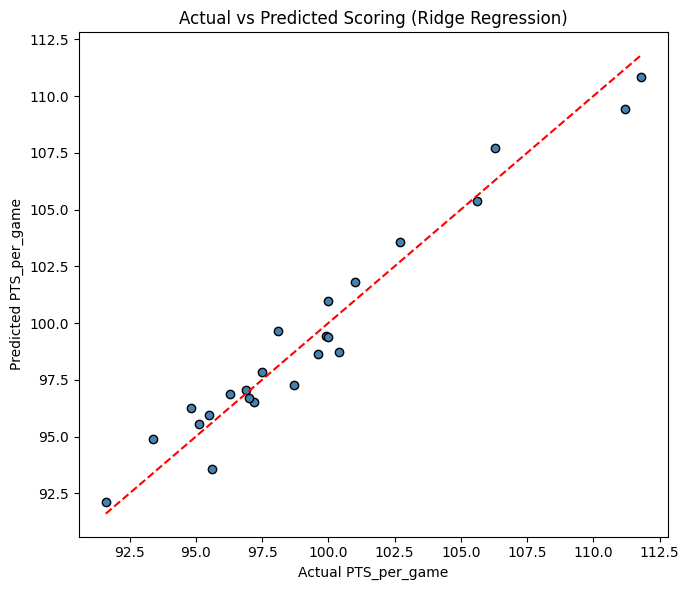

In [4]:
best_regression_name = regression_results_df.iloc[0]["Model"]
best_regression_predictions = regression_predictions[best_regression_name]

plt.figure(figsize=(7, 6))
plt.scatter(y_reg, best_regression_predictions, color="steelblue", edgecolors="black")
plt.plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()], color="red", linestyle="--")
plt.xlabel("Actual PTS_per_game")
plt.ylabel("Predicted PTS_per_game")
plt.title(f"Actual vs Predicted Scoring ({best_regression_name})")
plt.tight_layout()
plt.show()

In [5]:
# Fit the ridge model on the full dataset to interpret standardized coefficients.
ridge_model = regression_models["Ridge Regression"]
ridge_model.fit(X_reg, y_reg)

ridge_coefficients = pd.DataFrame({
    "Feature": regression_features,
    "Coefficient": ridge_model.named_steps["model"].coef_
}).sort_values("Coefficient", ascending=False)

ridge_coefficients

,Feature,Coefficient
3,Pace,2.603648
0,3PA,1.299948
1,3P_percent,0.752465
2,ThreePointShare,0.559626


### Regression Interpretation

Use this section in your report:

- The regression task evaluates whether league scoring can be predicted from three-point usage, three-point efficiency, three-point scoring share, and pace.
- LOOCV is preferred because the sample size is very small and we want to use almost all data for training in each split.
- If the cross-validated R-squared is high and RMSE is low, that supports the idea that NBA scoring is strongly associated with changes in playing style variables.
- Ridge regression is included to stabilize the model when features are correlated with each other.

## 4. Classification Task: Early Era vs Modern Era

Target:
- `Era_binary` where `0 = Early` and `1 = Modern`

Features:
- `3PA`
- `3P_percent`
- `ThreePointShare`
- `Pace`
- `PTS_per_game`

Models:
- Logistic Regression
- Decision Tree Classifier

Validation strategy:
- Stratified K-Fold cross-validation to preserve the 12/12 class balance in each split

In [6]:
classification_features = ["3PA", "3P_percent", "ThreePointShare", "Pace", "PTS_per_game"]
X_cls = df[classification_features]
y_cls = df["Era_binary"]

classification_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(random_state=42))
    ]),
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=42),
}

cv = StratifiedKFold(n_splits=6, shuffle=True, random_state=42)

classification_results = []
classification_predictions = {}

for name, model in classification_models.items():
    preds = cross_val_predict(model, X_cls, y_cls, cv=cv)
    classification_predictions[name] = preds
    classification_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_cls, preds),
        "Precision": precision_score(y_cls, preds),
        "Recall": recall_score(y_cls, preds),
        "F1": f1_score(y_cls, preds),
    })

classification_results_df = pd.DataFrame(classification_results).sort_values("Accuracy", ascending=False)
classification_results_df

,Model,Accuracy,Precision,Recall,F1
1,Decision Tree,0.875000,0.909091,0.833333,0.869565
0,Logistic Regression,0.833333,0.900000,0.750000,0.818182


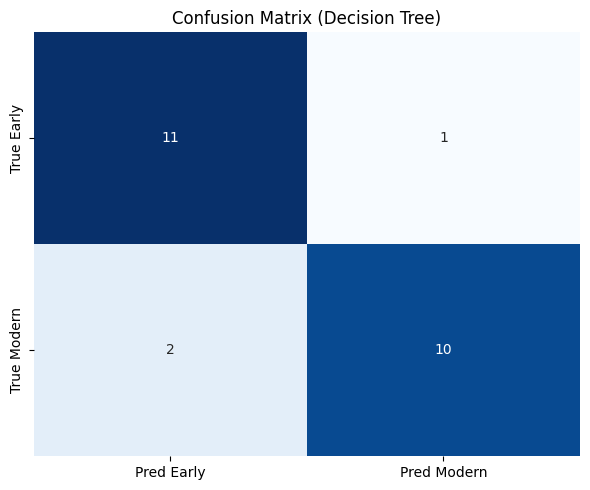

In [7]:
best_classifier_name = classification_results_df.iloc[0]["Model"]
best_classifier_predictions = classification_predictions[best_classifier_name]

cm = confusion_matrix(y_cls, best_classifier_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Pred Early", "Pred Modern"],
            yticklabels=["True Early", "True Modern"])
plt.title(f"Confusion Matrix ({best_classifier_name})")
plt.tight_layout()
plt.show()

In [8]:
# Fit logistic regression on the full dataset for interpretability.
logistic_model = classification_models["Logistic Regression"]
logistic_model.fit(X_cls, y_cls)

logistic_coefficients = pd.DataFrame({
    "Feature": classification_features,
    "Coefficient": logistic_model.named_steps["model"].coef_[0]
}).sort_values("Coefficient", ascending=False)

logistic_coefficients

,Feature,Coefficient
0,3PA,1.141705
2,ThreePointShare,0.863696
4,PTS_per_game,0.658321
3,Pace,0.614343
1,3P_percent,0.107013


### Classification Interpretation

Use this section in your report:

- This task asks whether a model can distinguish early and modern NBA seasons based only on league-wide style metrics.
- Strong classification performance would support the claim that modern NBA seasons are measurably different from earlier ones.
- Logistic regression is especially useful because its coefficients show which variables push a season toward the modern era label.
- The decision tree provides a simple non-linear comparison and can reveal threshold-based rules such as high three-point volume or high scoring.

## 5. Final Discussion

Suggested conclusion for this notebook:

- The ML section complements the EDA and hypothesis tests by moving from description to prediction.
- Regression tests whether scoring can be predicted from three-point-related variables and pace.
- Classification tests whether the statistical profile of a season is distinctive enough for a model to identify its era.
- If both tasks perform well, that strengthens the argument that the rise of three-point shooting reflects a broader structural change in NBA playing style.

Limitations:

- The dataset is very small, so results should be interpreted carefully.
- Seasons are temporally ordered, which limits the independence assumption of standard ML validation.
- The era label is based on a midpoint split, so classification does not discover the breakpoint by itself.